# Лабораторная работа E12 — Управление схватом протеза и оценка управляемости

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e12.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e12.html)**.

**Что разбираем.** Классификатор из E7 и регрессия из E9 выдают числа. Чтобы
число стало движением, нужен **маппинг** — правило, переводящее уровень
сигнала в положение схвата. Способов ровно два, и выбор между ними
определяет, каким протез окажется в руках:

* **бинарный** — есть порог: выше него схват закрыт, ниже открыт. Просто,
  надёжно, но взять яйцо таким схватом нельзя;
* **пропорциональный** — угол схвата следует за уровнем: θ = L/100 · 90°.
  Позволяет дозировать усилие, но передаёт наверх весь шум сигнала.

Уровень берём из реальной записи так же, как в E9: каузальная RMS-огибающая
по всем восьми каналам, приведённая к шкале 0–100.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
# ЯЧЕЙКА 2 · Признаки ЭМГ и нарезка на окна.
# Это «чёрный ящик» лабы: запусти один раз и дальше просто вызывай функции.
# Внутри — классический набор Хадгинса (Hudgins et al., 1993) плюс две
# частотные характеристики. Разбираться в реализации не нужно.

FS = 1000.0          # частота дискретизации записи, Гц
N_CH = 8             # каналов в браслете

TD_NAMES = ["MAV", "RMS", "WL", "ZC", "SSC"]
FREQ_NAMES = ["MDF", "MNF"]


def window_signal(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None, purity=0.6):
    """Режет запись X[N, C] с метками y[N] на скользящие окна.

    Метка окна — самый частый класс внутри него. Окно на стыке двух жестов
    (ни один класс не занимает purity доли окна) выбрасывается.
    Возвращает (windows[K, W, C], labels[K]).
    """
    width = int(round(win_ms / 1000.0 * fs))
    step = int(round(step_ms / 1000.0 * fs))
    keep = set(range(1, 8)) if keep is None else set(keep)
    wins, labs = [], []
    for start in range(0, len(X) - width + 1, step):
        chunk = y[start:start + width]
        values, counts = np.unique(chunk, return_counts=True)
        label = int(values[np.argmax(counts)])
        if label not in keep or counts.max() < purity * width:
            continue
        wins.append(X[start:start + width, :])
        labs.append(label)
    if not wins:
        return np.empty((0, width, X.shape[1])), np.empty((0,), int)
    return np.asarray(wins), np.asarray(labs, int)


def td_features(x, rel_eps=0.02):
    """Пять признаков Хадгинса по одному каналу.

    MAV — средний модуль (насколько сильно напряжена мышца);
    RMS — эффективная амплитуда (то же, что в лабе E4);
    WL  — суммарная длина кривой, мера «изрезанности»;
    ZC  — сколько раз сигнал пересёк ноль (грубая оценка частоты);
    SSC — сколько раз сменился знак наклона (тоже про частоту).

    ZC и SSC считают с мёртвой зоной rel_eps от уровня сигнала: без неё они
    считали бы дрожание нуля, а не настоящие колебания.
    """
    eps = rel_eps * np.sqrt(np.mean(x ** 2)) + 1e-12
    diff = np.diff(x)
    zc = int(np.sum((x[:-1] * x[1:] < 0) & (np.abs(diff) > eps)))
    d1, d2 = x[1:-1] - x[:-2], x[1:-1] - x[2:]
    ssc = int(np.sum((d1 * d2 > 0) & ((np.abs(d1) > eps) | (np.abs(d2) > eps))))
    return np.array([np.mean(np.abs(x)), np.sqrt(np.mean(x ** 2)),
                     np.sum(np.abs(diff)), zc, ssc], float)


def freq_features(x, fs=FS):
    """MDF и MNF — медианная и средняя частоты спектра мощности канала.

    MDF делит энергию спектра пополам, MNF — центр масс спектра. Обе падают
    при утомлении мышцы, поэтому их считают вместе с амплитудными.
    """
    x = x - np.mean(x)
    power = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = power.sum() + 1e-24
    cumulative = np.cumsum(power)
    mdf = freqs[np.searchsorted(cumulative, cumulative[-1] / 2)]
    return np.array([mdf, np.sum(freqs * power) / total], float)


def features_window(win, fs=FS):
    """Одно окно win[W, C] → один длинный вектор чисел: 7 признаков на канал."""
    return np.concatenate([
        np.concatenate([td_features(win[:, c]), freq_features(win[:, c], fs)])
        for c in range(win.shape[1])])


def feature_names(n_ch=N_CH):
    """Имена координат вектора признаков — в том же порядке, что и значения."""
    return ["ch%d_%s" % (c + 1, nm)
            for c in range(n_ch) for nm in TD_NAMES + FREQ_NAMES]


def features_of(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None):
    """Запись → матрица признаков. Возвращает (Xf[K, D], labels[K])."""
    wins, labs = window_signal(X, y, fs, win_ms, step_ms, keep)
    return np.array([features_window(w, fs) for w in wins]), labs

In [3]:
# ЯЧЕЙКА 3 · Данные: скачиваем настоящий датасет.
# Работаем не на выдумке, а на открытой записи UCI «EMG Data for Gestures»
# (Lobov et al., 2018): 36 человек, браслет MYO — восемь электродов по
# окружности предплечья, по две серии на человека, размеченные жесты.
# Архив ~17 МБ, качается один раз за сессию. Ничего ставить руками не нужно.

import os
import glob
import urllib.request
import zipfile

DATA_URL = "https://archive.ics.uci.edu/static/public/481/emg+data+for+gestures.zip"
DATA_DIR = "EMG_data_for_gestures-master"

GESTURE_NAMES = {
    0: "неразмечено", 1: "покой", 2: "кулак", 3: "сгибание",
    4: "разгибание", 5: "радиальное", 6: "локтевое", 7: "ладонь",
}


def fetch_dataset(url=DATA_URL, directory=DATA_DIR):
    """Скачивает и распаковывает датасет. Повторный вызов ничего не делает."""
    # Печатаем только имя папки, без полного пути: путь на чужой машине
    # читателю ничего не говорит, а в сохранённом выводе ноутбука остаётся.
    directory = os.environ.get("EMG_DATA_DIR", directory)
    name = os.path.basename(directory.rstrip("/\\")) or directory
    if os.path.isdir(directory):
        print("Датасет уже на месте:", name)
        return directory
    print("Скачиваю архив (~17 МБ)...")
    archive, _ = urllib.request.urlretrieve(url)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(".")
    os.remove(archive)
    print("Готово:", name)
    return directory


def list_subjects(directory=DATA_DIR):
    """Номера доступных испытуемых: '01', '02', ... '36'."""
    return sorted(d for d in os.listdir(directory)
                  if d.isdigit() and os.path.isdir(os.path.join(directory, d)))


def subject_files(subject, directory=DATA_DIR):
    """Файлы одного человека — обычно две серии, записанные подряд."""
    pattern = os.path.join(directory, str(subject).zfill(2), "*_raw_data_*.txt")
    return sorted(glob.glob(pattern))


def load_record(path):
    """Один файл записи → (X[N, 8], y[N]).

    В файле десять столбцов: время в мс, восемь каналов и метка жеста.
    Шаг времени 1 мс, отсюда FS = 1000 Гц. Метка 0 — участок без разметки.
    Каналы переводим из вольт в милливольты, иначе все числа выглядят как
    0.00002 и читать их невозможно.
    """
    data = np.loadtxt(path, skiprows=1)
    return data[:, 1:9] * 1000.0, data[:, 9].astype(int)


def plot_record(X, y, fs=FS, seconds=12.0, channels=(0, 2, 4, 6)):
    """Кусок записи: как выглядят каналы и где какой жест был размечен."""
    n = min(len(X), int(seconds * fs))
    t = np.arange(n) / fs
    present = sorted(set(int(v) for v in np.unique(y[:n])))
    fig, axes = plt.subplots(len(channels) + 1, 1, sharex=True,
                             figsize=(12, 1.4 * len(channels) + 2.4))
    for ax, c in zip(axes, channels):
        ax.plot(t, X[:n, c], lw=0.6, color="steelblue")
        ax.set_ylabel("кан. %d" % (c + 1))
    axes[-1].step(t, y[:n], where="post", color="darkorange", lw=1.6)
    axes[-1].set(xlabel="$t$, с", ylabel="жест", yticks=present)
    axes[-1].set_yticklabels([GESTURE_NAMES[v] for v in present])
    axes[0].set_title("Запись браслета MYO: четыре канала из восьми и разметка жестов")
    fig.tight_layout()
    plt.show()


def class_table(y, title="Распределение по классам"):
    """Сколько окон (или отсчётов) пришлось на каждый класс."""
    values, counts = np.unique(y, return_counts=True)
    print(title + ":")
    for v, c in zip(values, counts):
        print("   %-12s %6d" % (GESTURE_NAMES[int(v)], c))

## Ячейка 4 · Считаем уровень сигнала вдоль записи

Каузально: на каждом шаге смотрим только назад, на последние `WIN_MS`. Так
же, как это делал бы контроллер в протезе.

In [4]:
WIN_MS = 200.0
STEP_MS = 25.0                  # 40 обновлений команды в секунду

root = fetch_dataset()
X, y = load_record(subject_files("01", root)[0])

width = int(WIN_MS / 1000.0 * FS)
step = int(STEP_MS / 1000.0 * FS)
starts = range(0, len(X) - width + 1, step)

raw_level = np.array([np.mean(np.sqrt(np.mean(X[s:s + width] ** 2, axis=0)))
                      for s in starts])
low, high = np.percentile(raw_level, 2), np.percentile(raw_level, 98)
level = np.clip((raw_level - low) / (high - low + 1e-12), 0, 1) * 100.0
time = np.arange(len(level)) * STEP_MS / 1000.0

print("Шагов потока: %d (%.1f с записи), обновление каждые %.0f мс"
      % (len(level), len(X) / FS, STEP_MS))
print("Уровень: медиана %.0f, максимум %.0f" % (np.median(level), level.max()))

Датасет уже на месте: EMG_data_for_gestures-master
Шагов потока: 2520 (63.2 с записи), обновление каждые 25 мс
Уровень: медиана 28, максимум 100


## Ячейка 5 · Сглаживание, порог и гистерезис

Сырой уровень дрожит, и у самого порога команда будет метаться. Лечится
двумя средствами: экспоненциальным сглаживанием и **гистерезисом** —
закрываем схват при `L ≥ ПОРОГ`, а открываем только при
`L < ПОРОГ − ГИСТЕРЕЗИС`. Зазор между этими двумя уровнями и убирает дребезг.

In [5]:
SMOOTH = 0.4                    # 0 — без сглаживания, ближе к 1 — сильнее
THRESHOLD = 40.0                # порог закрытия схвата, в шкале 0–100
HYSTERESIS = 8.0                # насколько ниже порога нужно упасть, чтобы открыть


def smooth_ema(values, alpha=SMOOTH):
    """Экспоненциальное сглаживание: помнит прошлое с весом alpha."""
    out, state = np.empty_like(values), 0.0
    for i, value in enumerate(values):
        state = alpha * state + (1.0 - alpha) * value
        out[i] = state
    return out


def binary_angle(values, threshold=THRESHOLD, hysteresis=HYSTERESIS):
    """Бинарный маппинг: 0° открыт, 90° закрыт. Возвращает (углы, переключений)."""
    out, closed, flips = np.empty_like(values), False, 0
    for i, value in enumerate(values):
        if not closed and value >= threshold:
            closed, flips = True, flips + 1
        elif closed and value < threshold - hysteresis:
            closed, flips = False, flips + 1
        out[i] = 90.0 if closed else 0.0
    return out, flips


def proportional_angle(values):
    """Пропорциональный маппинг: весь диапазон уровня в 0–90°."""
    return np.clip(values, 0, 100) / 100.0 * 90.0


smooth = smooth_ema(level)
angle_binary, flips = binary_angle(smooth)
angle_prop = proportional_angle(smooth)

_, flips_no_hysteresis = binary_angle(smooth, hysteresis=0.0)
_, flips_raw = binary_angle(level, hysteresis=0.0)

print("Переключений схвата за запись:")
print("   без сглаживания и без гистерезиса: %d" % flips_raw)
print("   только сглаживание:                %d" % flips_no_hysteresis)
print("   сглаживание и гистерезис:          %d" % flips)

Переключений схвата за запись:
   без сглаживания и без гистерезиса: 74
   только сглаживание:                68
   сглаживание и гистерезис:          32


## Ячейка 6 · Два маппинга на одном сигнале

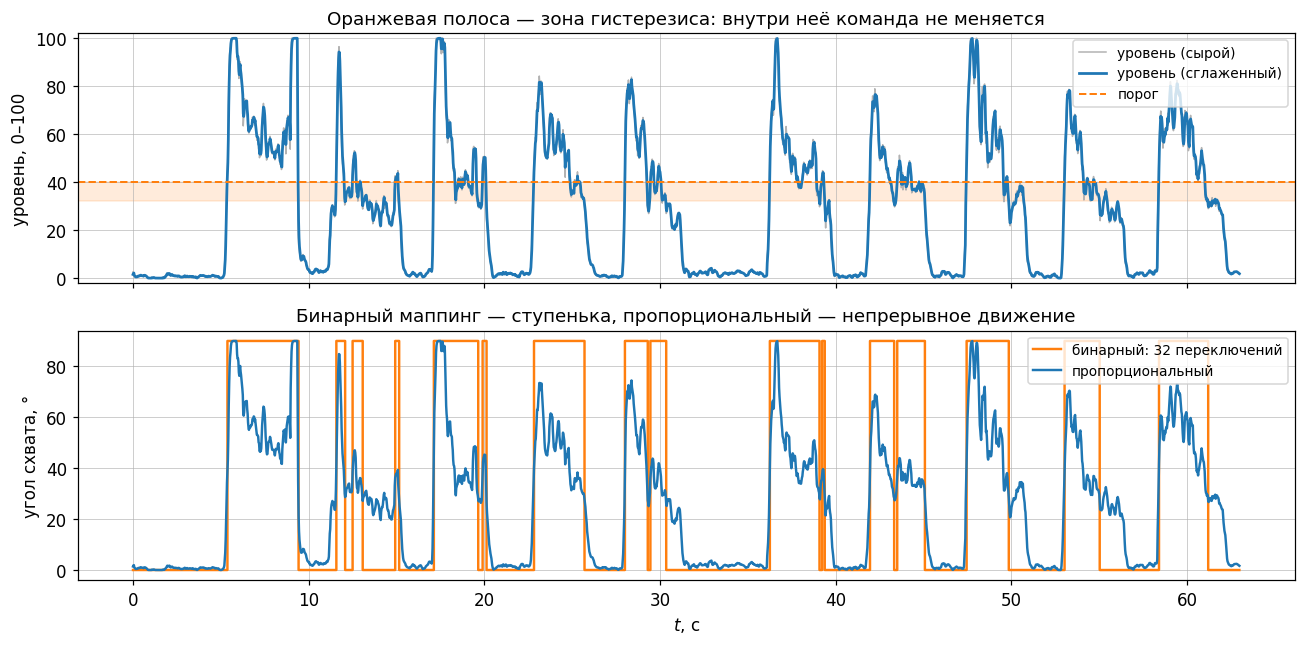

In [6]:
fig, (top, bottom) = plt.subplots(2, 1, sharex=True, figsize=(12, 6.0))

top.plot(time, level, color="0.7", lw=1.0, label="уровень (сырой)")
top.plot(time, smooth, color="tab:blue", lw=1.8, label="уровень (сглаженный)")
top.axhline(THRESHOLD, color="tab:orange", ls="--", lw=1.3, label="порог")
top.axhspan(THRESHOLD - HYSTERESIS, THRESHOLD, color="tab:orange", alpha=0.15)
top.set(ylabel="уровень, 0–100", ylim=(-2, 102),
        title="Оранжевая полоса — зона гистерезиса: внутри неё команда не меняется")
top.legend(fontsize=9, loc="upper right")

bottom.step(time, angle_binary, where="post", color="tab:orange", lw=1.6,
            label="бинарный: %d переключений" % flips)
bottom.plot(time, angle_prop, color="tab:blue", lw=1.6,
            label="пропорциональный")
bottom.set(xlabel="$t$, с", ylabel="угол схвата, °", ylim=(-4, 94),
           title="Бинарный маппинг — ступенька, пропорциональный — непрерывное движение")
bottom.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

## Ячейка 7 · Чем платит пропорциональный маппинг

У бинарного схвата шум сигнала виден только на переключениях. У
пропорционального он идёт прямо в двигатель: схват мелко дрожит всё время,
пока мышца напряжена. Померим это — суммарным ходом схвата за всю запись.

In [7]:
def travel(angles):
    """Суммарный ход схвата в градусах: сколько всего он наездил."""
    return float(np.sum(np.abs(np.diff(angles))))


print("Полный ход схвата за %.0f с записи:" % time[-1])
print("   бинарный:                  %7.0f°" % travel(angle_binary))
print("   пропорциональный:          %7.0f°" % travel(angle_prop))
print("   пропорциональный без сглаживания: %.0f°" % travel(proportional_angle(level)))
print("\nБинарный схват двигается только по делу: %d переключений по 90°."
      % flips)
print("У пропорционального к этому добавляется постоянное мелкое дрожание —")
print("износ механики и разряд батареи. Сглаживание убирает %.0f° хода."
      % (travel(proportional_angle(level)) - travel(angle_prop)))

Полный ход схвата за 63 с записи:
   бинарный:                     2880°
   пропорциональный:             3131°
   пропорциональный без сглаживания: 3824°

Бинарный схват двигается только по делу: 32 переключений по 90°.
У пропорционального к этому добавляется постоянное мелкое дрожание —
износ механики и разряд батареи. Сглаживание убирает 694° хода.


## Задания

1. Подбери `THRESHOLD` и `HYSTERESIS` так, чтобы число переключений совпало с
   числом реальных сжатий на записи. Приложи верхний график с порогом.
2. Прогони `SMOOTH` = 0, 0.4, 0.8, 0.95 и построй зависимость полного хода
   пропорционального схвата от `SMOOTH`. Что портится при больших значениях?
3. Предложи смешанный маппинг: до порога схват не двигается, после —
   пропорционально остатку уровня. Реализуй и сравни полный ход с обоими
   базовыми вариантами.